In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Case2.csv')

print(df.describe())

           Count
count  13.000000
mean   26.153846
std    21.094415
min     7.000000
25%    11.000000
50%    19.000000
75%    37.000000
max    76.000000


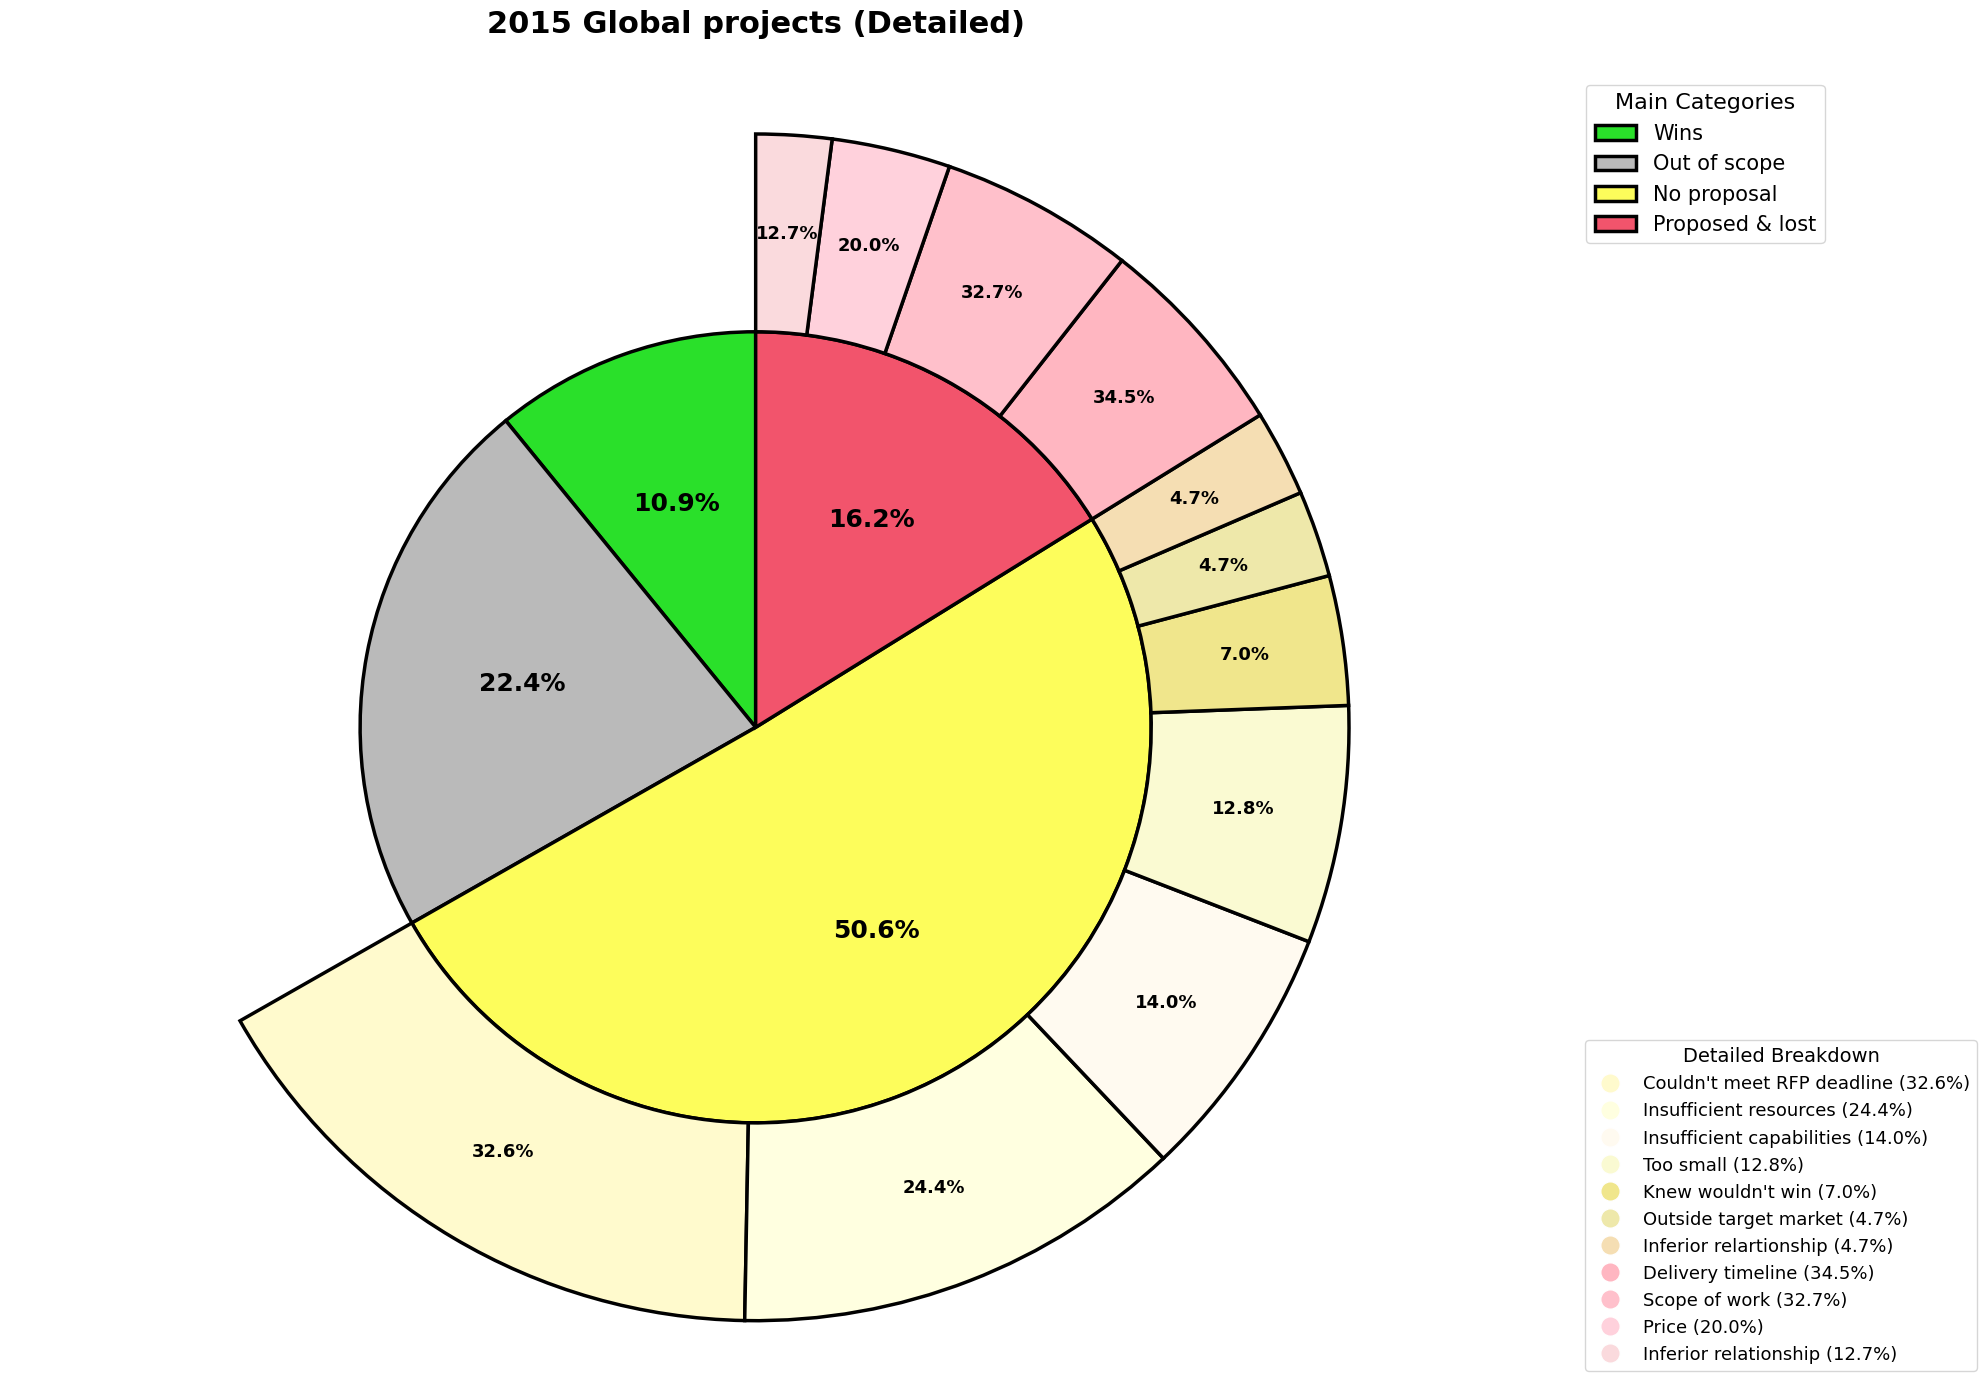

In [3]:
wins = df[df['Category'] == 'Wins']['Count'].sum()
out_of_scope = df[df['Category'] == 'Out of scope']['Count'].sum()

no_proposal_items = ['Couldn\'t meet RFP deadline', 'Insufficient resources', 
                     'Insufficient capabilities', 'Too small', 'Knew wouldn\'t win', 
                     'Outside target market', 'Inferior relartionship']
no_proposal_data = df[df['Category'].isin(no_proposal_items)]
no_proposal_total = no_proposal_data['Count'].sum()

proposed_lost_items = ['Delivery timeline', 'Scope of work', 'Price', 'Inferior relationship']
proposed_lost_data = df[df['Category'].isin(proposed_lost_items)]
proposed_lost_total = proposed_lost_data['Count'].sum()

inner_data = [wins, out_of_scope, no_proposal_total, proposed_lost_total]
inner_labels = ['Wins', 'Out of scope', 'No proposal', 'Proposed & lost']
inner_colors = ["#2AE02A", "#BABABA", "#FDFD5B", "#F2546C"]

outer_data = list(no_proposal_data['Count']) + list(proposed_lost_data['Count'])

outer_colors_detail = []
outer_colors_detail += ["#FFFACD", "#FFFFE0", "#FFFAF0", "#FAFAD2", "#F0E68C", "#EEE8AA", "#F5DEB3"]
outer_colors_detail += ["#FFB6C1", "#FFC0CB", "#FFD1DC", "#FADADD"]

no_proposal_percents = [(count / no_proposal_total * 100) for count in no_proposal_data['Count']]
proposed_lost_percents = [(count / proposed_lost_total * 100) for count in proposed_lost_data['Count']]

fig, ax = plt.subplots(figsize=(20, 14))

wedges_inner, texts_inner, autotexts_inner = ax.pie(
    inner_data,
    labels=None,
    autopct='%1.1f%%',
    colors=inner_colors,
    radius=1.0,
    startangle=90,
    wedgeprops={'edgecolor': 'black', 'linewidth': 2.5}
)

for autotext in autotexts_inner:
    autotext.set_color('black')
    autotext.set_fontsize(18)
    autotext.set_fontweight('bold')

outer_data_full = [wins, out_of_scope] + outer_data
outer_colors_full = ['none', 'none'] + outer_colors_detail

wedges_outer, texts_outer = ax.pie(
    outer_data_full, 
    labels=None,
    colors=outer_colors_full,
    radius=1.5,
    startangle=90,
    wedgeprops={'edgecolor': 'black', 'linewidth': 2.5, 'width': 0.5},
    textprops={'fontsize': 13, 'fontweight': 'bold'}
)

for i, wedge in enumerate(wedges_outer):
    if i < 2:
        wedge.set_edgecolor('none')

outer_autopct = ['', ''] + [f'{p:.1f}%' for p in no_proposal_percents] + [f'{p:.1f}%' for p in proposed_lost_percents]

for i, (wedge, pct) in enumerate(zip(wedges_outer, outer_autopct)):
    if pct:
        angle = (wedge.theta2 - wedge.theta1) / 2 + wedge.theta1
        x = 1.25 * np.cos(np.radians(angle))
        y = 1.25 * np.sin(np.radians(angle))
        ax.text(x, y, pct, ha='center', va='center', fontsize=13, fontweight='bold')

plt.title('2015 Global projects (Detailed)', fontsize=22, fontweight='bold', pad=30)
ax.axis('equal')

legend1 = plt.legend(inner_labels, loc='upper left', bbox_to_anchor=(1.05, 1), 
                     fontsize=15, title='Main Categories', title_fontsize=16, frameon=True)
plt.gca().add_artist(legend1)

detail_labels_yellow = [f"{cat} ({pct:.1f}%)" 
                        for cat, pct in zip(no_proposal_data['Category'], no_proposal_percents)]
detail_labels_red = [f"{cat} ({pct:.1f}%)" 
                     for cat, pct in zip(proposed_lost_data['Category'], proposed_lost_percents)]

detail_labels = detail_labels_yellow + detail_labels_red
detail_colors = outer_colors_detail

legend2 = plt.legend([plt.Line2D([0], [0], marker='o', color='w', 
                                 markerfacecolor=detail_colors[i], markersize=14) 
                      for i in range(len(detail_labels))],
                     detail_labels, loc='lower left', bbox_to_anchor=(1.05, 0), 
                     fontsize=13, title='Detailed Breakdown', title_fontsize=14, frameon=True)

plt.tight_layout()
plt.show()
